# Landsat Collection 2 Level-2

**Nostradamus - Cube in a Box Demo Series**

---

*   **Objective:** Process and visualize Landsat C2 L2 Surface Reflectance and Temperature.
*   **Products used:** [`ls89_c2l2_sp`](http://localhost/explorer/products/ls89_c2l2_sp)
*   **Source:** [Planetary Computer Catalog](https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2)

---

## Background

Landsat Collection 2 Level-2 Science Products, consisting of atmospherically corrected surface reflectance and surface temperature image data. Collection 2 Level-2 Science Products are available from August 22, 1982 to present.

This dataset represents the global archive of Level-2 data from Landsat Collection 2 acquired by the Thematic Mapper onboard Landsat 4 and 5, the Enhanced Thematic Mapper onboard Landsat 7, and the Operatational Land Imager and Thermal Infrared Sensor onboard Landsat 8 and 9.

## Description

This notebook covers DN to SR/ST scaling, using Dask for parallel processing, and basic visualization of Landsat bands.

***

In [1]:
import sys
sys.path.insert(1, '../utils/')

In [2]:
# reload module before executing code
%load_ext autoreload
%autoreload 2
%matplotlib inline

import psutil
import time
import datacube
import numpy as np
import matplotlib.pyplot as plt
from dask.distributed import Client
from odc.geo import BoundingBox
from IPython.display import HTML, display
from utils.deafrica_plotting import rgb
from utils.nostra_dc import get_product_bbox
from utils.nostra_mapping import bbox_to_polygon, display_crosshair, get_utm_epsg_code, MapHandler
from utils.nostra_masking import qa_pixel_mask
from utils.nostra_tools import style_output_cells

from planetary_computer import sign_url  # needed to access planetary-computer collection

### Connect to the datacube

In [3]:
dc = datacube.Datacube(app="Landsat_Science_Products")

## Available products and measurements

### List products

In [4]:
# We can use datacube's list_measurements functionality to list cubes products that are available.

dc_measurements = dc.list_measurements()
products = set([item[0] for item in dc_measurements.index])
for product in products:
    print(product)

ls7_c2l2_sp
ls89_c2l2_sp
sentinel_1_rtc
s2_l2a
ls45_c2l2_sp
io_lulc_annual_v02
nasadem


In [5]:
# Let's inspect one of the three Landsat products available (starting with "ls").

product = 'ls89_c2l2_sp'
dc.list_measurements().loc[product]

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
coastal,coastal,uint16,1,0.0,"[SR_B1, band_1, coastal_aerosol]",NaN
blue,blue,uint16,1,0.0,"[SR_B2, band_2]",NaN
green,green,uint16,1,0.0,"[SR_B3, band_3]",NaN
red,red,uint16,1,0.0,"[SR_B4, band_4]",NaN
nir08,nir08,uint16,1,0.0,"[SR_B5, band_5]",NaN
swir16,swir16,uint16,1,0.0,"[SR_B6, band_6, swir_1]",NaN
swir22,swir22,uint16,1,0.0,"[SR_B7, band_7, swir_2]",NaN
qa_pixel,qa_pixel,uint16,bit_index,1.0,"[pixel_qa, pq, pixel_quality]","{'snow': {'bits': 5, 'values': {'0': 'not_high..."
qa_radsat,qa_radsat,uint16,bit_index,0.0,"[QA_RADSAT, radsat, radiometric_saturation]","{'nir_saturation': {'bits': 4, 'values': {'0':..."


### Dask dashboard  
In order to optimise usage of your hardware it is recommended to run the next cells to configure Daskerisation and access Dask dashboard, which will allow you to monitor your hardware usage as well as Dask computation progress.  
![](./figures/dask_dashboard.png)

In [6]:
# Get the available cpu(s) number and memory in gigabytes (to properly configure Dask client in follwoing cell)

print(f"Available cpu(s): {psutil.cpu_count()}")

available_memory = psutil.virtual_memory().available
available_memory_gb = available_memory / (1024 ** 3)
print(f"Available memory: {available_memory_gb:.2f} GB")

Available cpu(s): 4
Available memory: 19.76 GB


In [7]:
try:
    client.dashboard_link
except:
    client = Client(n_workers=4, memory_limit='4GB')  # memory_limit PER WORKER !
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /jupyter/user/bruno/proxy/8787/status,
Dashboard: /jupyter/user/bruno/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36275,Workers: 0
Dashboard: /jupyter/user/bruno/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46341,Total threads: 1
Dashboard: /jupyter/user/bruno/proxy/41857/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:41511,


## Load Landsat Surface Reflectance

Now that we know what products and measurements are available for the products, we can load data from the datacube using `dc.load`.

In the example below, we will load Surface Reflectance from `ls89_c2l2_sp` product. By specifying `output_crs='EPSG:6933'` and `resolution=30`, we request that datacube reproject our data to the African Albers coordinate reference system (CRS), with 30 x 30 m pixels. Finally, `group_by='solar_day'` ensures that overlapping images taken within seconds of each other as the satellite passes over are combined into a single time step in the data.

In [8]:
# Check if default bbox is contained within the datacube
# and allow user to draw bbox if not.

product = "ls89_c2l2_sp"

# configure a default bounding box and visualize it
lat, lon = 22.821, 28.518
buffer = 0.05
default_bbox = (lon - buffer, lat - buffer, lon + buffer, lat + buffer)

product_bbox = get_product_bbox(dc, product, split_size=10, stability_threshold=4)

is_contained =(default_bbox[0] >= product_bbox[0] and
               default_bbox[1] >= product_bbox[1] and
               default_bbox[2] <= product_bbox[2] and
               default_bbox[3] <= product_bbox[3]
              )

In [9]:
# Create an instance of MapHandler
map_handler = MapHandler()
m, drc = map_handler.create_map(vect=[bbox_to_polygon(default_bbox), bbox_to_polygon(product_bbox)],
                               draw_rect=True)
display(m)

# append crosshair
time.sleep(2)  # make sure m is fully displayed
display_crosshair()

Map(center=[25.2644573, 29.9659165], controls=(AttributionControl(options=['position', 'prefix'], position='bo…

<IPython.core.display.Javascript object>

In [10]:
# Warn in case of full AoI
aoi_poly = map_handler.aoi_tupple

if aoi_poly is None:
    aoi_poly = tuple(default_bbox)
    if not is_contained:
        style_output_cells('salmon', border_color='red', border_width='2px')
        print('The area of interest polygon is located outside of the product extent.' + \
              '\nPlease draw a new area of interest in the previous cell.')
    else:
        # When is_contained is True and no polygon drawn - this is actually OK!
        style_output_cells()
        print('Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.')
else:
    # A polygon was drawn
    style_output_cells()
    print('Custom area of interest polygon has been created.')

Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.


In [11]:
# get EPSG code for the center of the AoI

epsg_code = get_utm_epsg_code((aoi_poly[1] + aoi_poly[3]) / 2, (aoi_poly[0] + aoi_poly[2]) / 2)

In [12]:
times = [ds.time.begin for ds in dc.find_datasets(product=product)]

start_date = min(times)
end_date = max(times)

In [13]:
import ipywidgets as widgets
start_date = widgets.DatePicker(description='Start date',
                                value = min(times).date(),
                                disabled=False)
end_date = widgets.DatePicker(description='End date',
                                value = max(times).date(),
                                disabled=False)
display(widgets.Label('IF REQUIRED define time period (cannot be outside of the initial displayed time) and run the next cell:'),
        widgets.HBox([start_date, end_date]))

Label(value='IF REQUIRED define time period (cannot be outside of the initial displayed time) and run the next…

In [14]:
# load data
lazy_ds = dc.load(
    product=product,
    measurements=['red', 'green', 'blue', 'qa_pixel'],
    output_crs=f"EPSG:{epsg_code}",
    x = (aoi_poly[0], aoi_poly[2]),
    y = (aoi_poly[1], aoi_poly[3]),
    time=(start_date.value.strftime('%Y-%m-%d'), end_date.value.strftime('%Y-%m-%d')),
  resolution=30,
  group_by="solar_day",
  dask_chunks={},
  patch_url=sign_url,
)
# customized chunking is less buggy when performed after loading !!!
lazy_ds = lazy_ds.chunk({"x": 512, "y": 512, "time": 1})
print(lazy_ds)

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 3, y: 374, x: 347)
Coordinates:
  * time         (time) datetime64[ns] 24B 2021-12-06T08:32:23.729238 ... 202...
  * y            (y) float64 3kB 2.53e+06 2.53e+06 ... 2.519e+06 2.519e+06
  * x            (x) float64 3kB 6.506e+05 6.506e+05 ... 6.609e+05 6.61e+05
    spatial_ref  int32 4B 32635
Data variables:
    red          (time, y, x) uint16 779kB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
    green        (time, y, x) uint16 779kB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
    blue         (time, y, x) uint16 779kB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
    qa_pixel     (time, y, x) uint16 779kB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
Attributes:
    crs:           EPSG:32635
    grid_mapping:  spatial_ref


***
So far only metadata was accessed (which explains why loading was fast) as we used `dask_chunks` option, which is called "lazy loading". The `rgb` function in next cell will load the data which will slow down the process (you will find more Dask example in [Sentinel_2.ipynb](Sentinel_2.ipynb)). If you opened the Dask client link above you will be able to monitor activity, and possibly adapt chunking parameters (in previous cell) for better efficiency and stability.
***

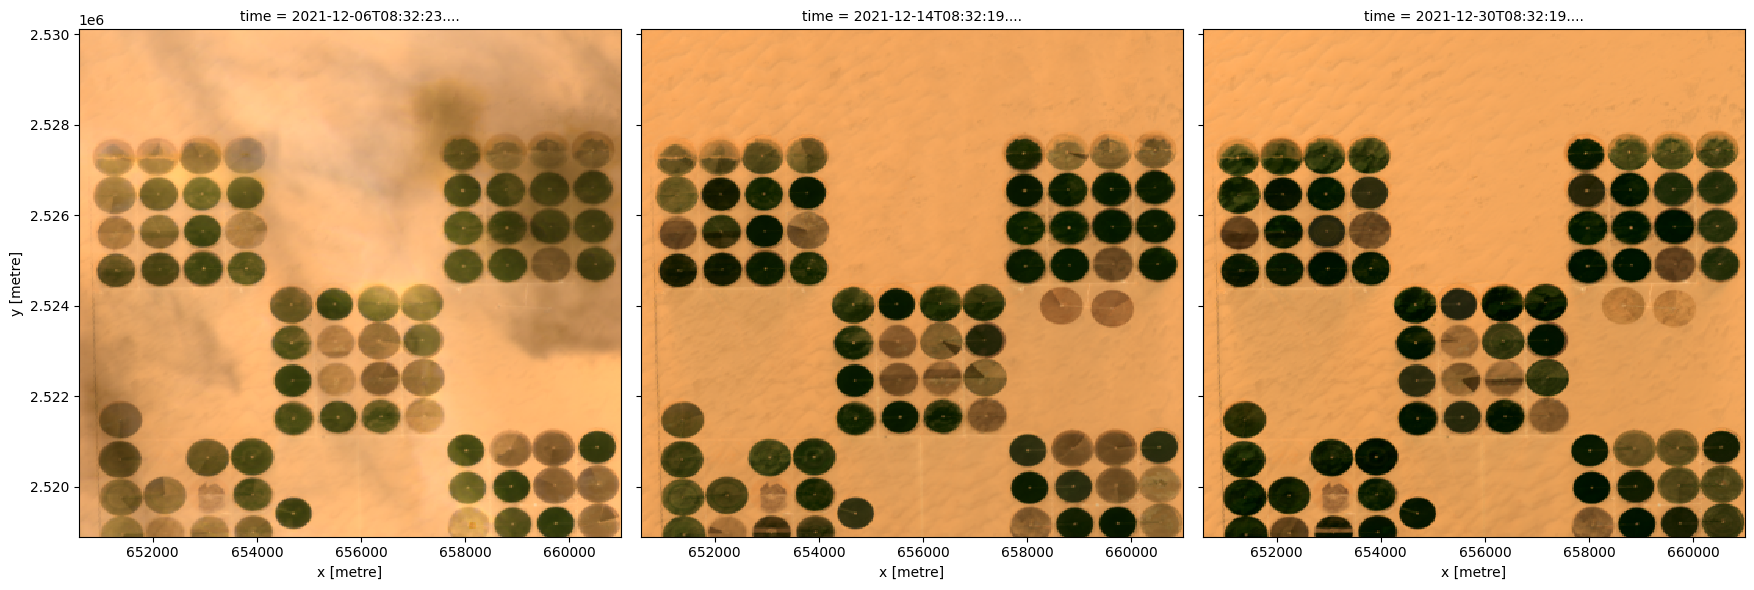

In [15]:
# Plot a composite of all scenes

rgb(lazy_ds, col="time", col_wrap=4)

In [16]:
%%time

# Plotting composite took time as the dataset needed to be computed by the function (in other words data
# (no metadata) needed to be accessed).
# As histograms in coming cell, imply to access the data, let's compute lazy_ds for once, which will avoid
# to re-compute it later and save time.

ds = lazy_ds.compute()

CPU times: user 147 ms, sys: 40.5 ms, total: 188 ms
Wall time: 1.05 s


## Remove pixels considered as nodata

In [17]:
mask_arr = (qa_pixel_mask(ds['qa_pixel'],'cloud') | 
            qa_pixel_mask(ds['qa_pixel'],'cloud_shadow') |
            qa_pixel_mask(ds['qa_pixel'],'dilated_cloud') |
            qa_pixel_mask(ds['qa_pixel'],'cirrus') |
            qa_pixel_mask(ds['qa_pixel'],'nodata'))
ds = ds.where(~mask_arr).drop_vars('qa_pixel')
ds = ds.dropna('time', how='all')  # Remove empty scenes

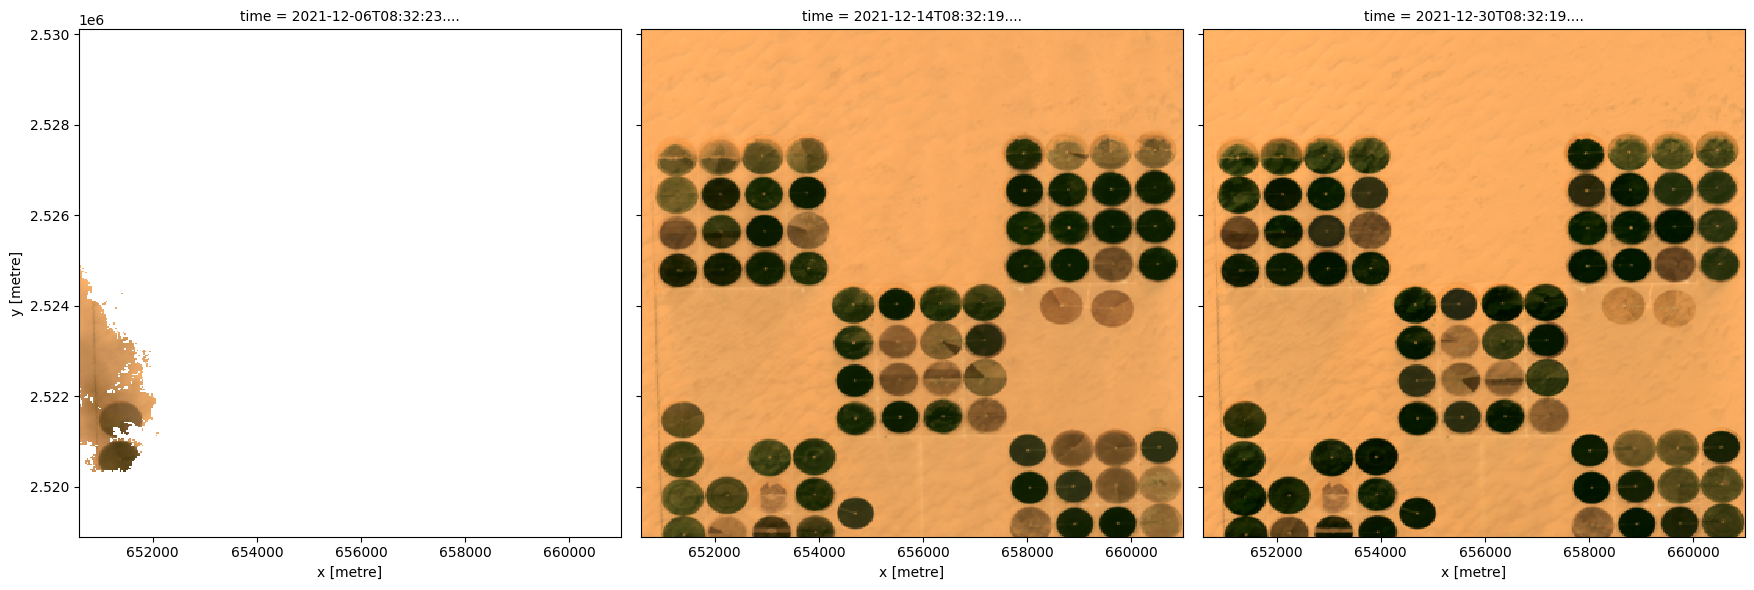

In [18]:
# Plot a composite of all scenes

rgb(ds, col="time", col_wrap=4)

## Convert Digital Numbers (DN) to Surface Reflectance (SR)

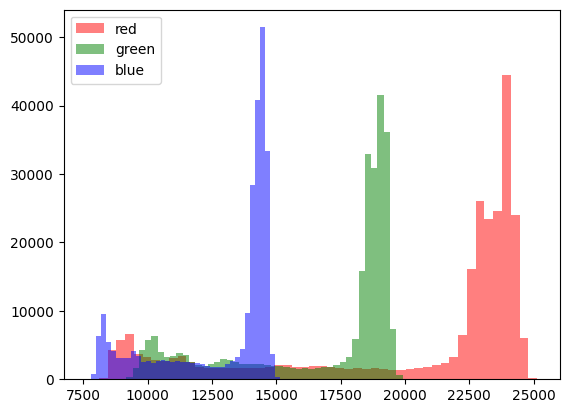

In [19]:
# Visualize distribution of each band

for v in ds.var():
    plt.hist(ds[v].values.flatten(), bins=50, alpha=0.5, label=v, color=v)
plt.legend()
plt.show()

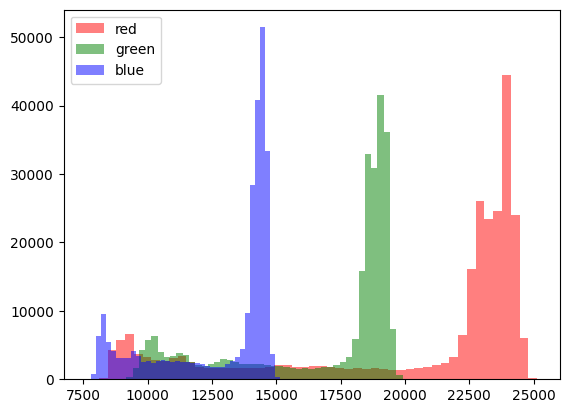

In [20]:
# First we need to make sure values are restricted to Valid Range. As selected bands have all the same
# Valid Range values we can do it at once

ds = ds.where((ds >= 7273) & (ds <= 43636), drop=True)

for v in ds.var():
    plt.hist(ds[v].values.flatten(), bins=50, alpha=0.5, label=v, color=v)
plt.legend()
plt.show()

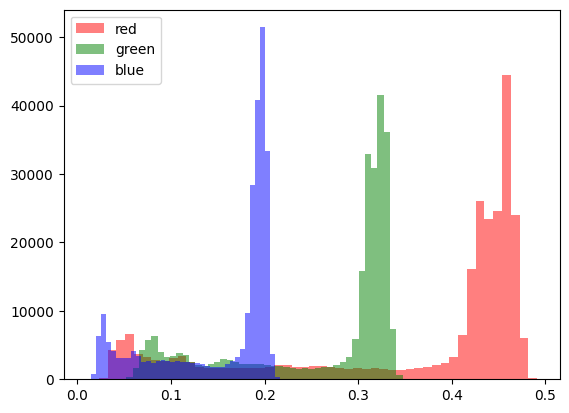

In [21]:
# Then convert DN to SR (with will give values between 0 and 1)

ds_sr = ds * 2.75e-5 - 0.2

for v in ds_sr.var():
    plt.hist(ds_sr[v].values.flatten(), bins=50, alpha=0.5, label=v, color=v)
plt.legend()
plt.show()

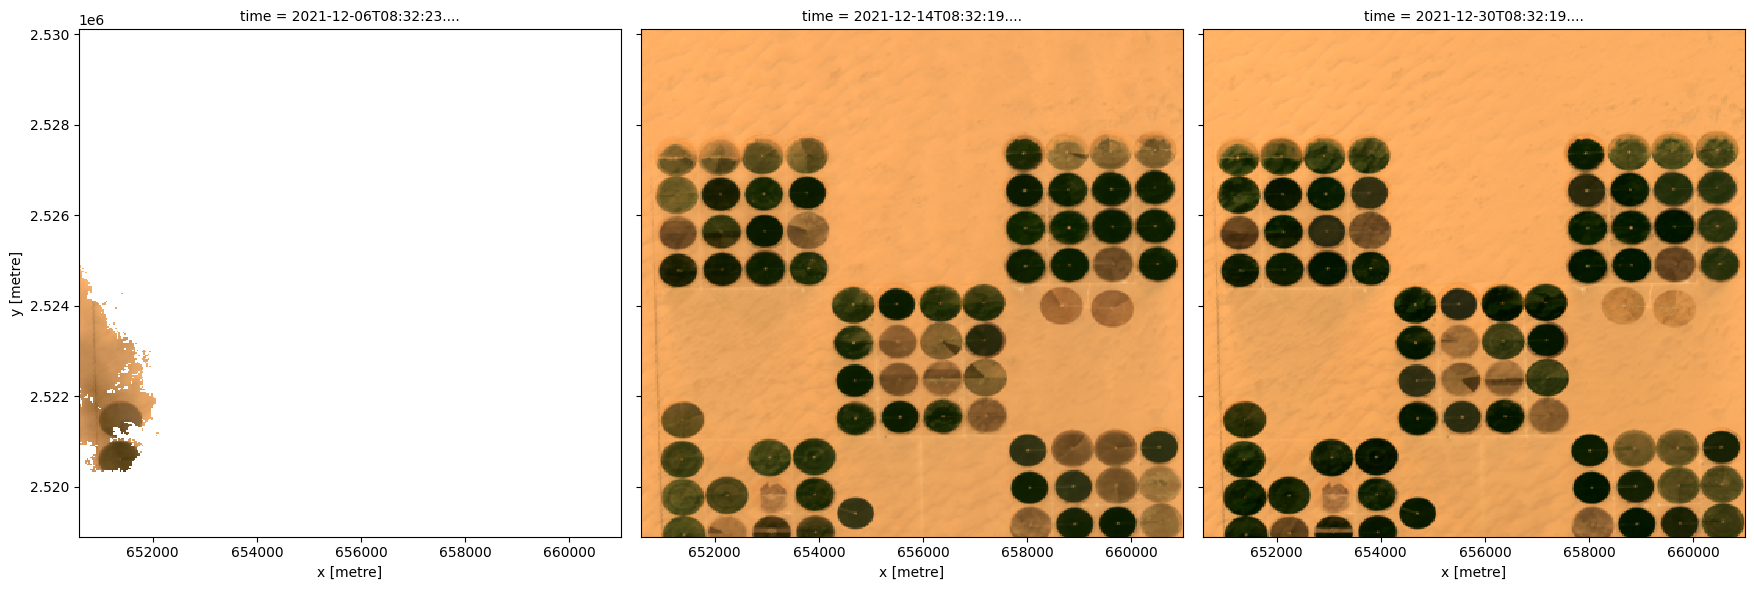

In [22]:
# Re-plotting a composite of all scenes should give approximately the same result
# (except for the values lost when restricting to Valid Range)

rgb(ds_sr, col="time", col_wrap=4)

## Load Landsat Surface Temperature

In the example below, we will load Surface Temperature, using almost the same parameters as previously. In such case it is recommended to create a query object with common parameters to be re-used. Let's do it for the demo.

In [23]:
# Create a query object

common_query = {
    'product': 'ls89_c2l2_sp',
    'output_crs': f"EPSG:{epsg_code}",
    'y': (aoi_poly[1], aoi_poly[3]),
    'x': (aoi_poly[0], aoi_poly[2]),
    'time': (start_date.value.strftime('%Y-%m-%d'), end_date.value.strftime('%Y-%m-%d')),
    'resolution': 30,
    'group_by': "solar_day",
    'patch_url': sign_url,
}

In [24]:
# Then load data using common_query
lazy_ds = dc.load(measurements=['surface_temperature', 'qa_pixel'],  # alias can also be used
                  dask_chunks={},
                  **common_query)

# customized chunking is less buggy when performed after loading !!!
lazy_ds = lazy_ds.chunk({"x": 512, "y": 512, "time": 1})

print(lazy_ds)

<xarray.Dataset> Size: 2MB
Dimensions:              (time: 3, y: 374, x: 347)
Coordinates:
  * time                 (time) datetime64[ns] 24B 2021-12-06T08:32:23.729238...
  * y                    (y) float64 3kB 2.53e+06 2.53e+06 ... 2.519e+06
  * x                    (x) float64 3kB 6.506e+05 6.506e+05 ... 6.61e+05
    spatial_ref          int32 4B 32635
Data variables:
    surface_temperature  (time, y, x) uint16 779kB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
    qa_pixel             (time, y, x) uint16 779kB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
Attributes:
    crs:           EPSG:32635
    grid_mapping:  spatial_ref


In [25]:
# compute Lazy_ds as plotting the dataset will require access to data

ds = lazy_ds.compute()

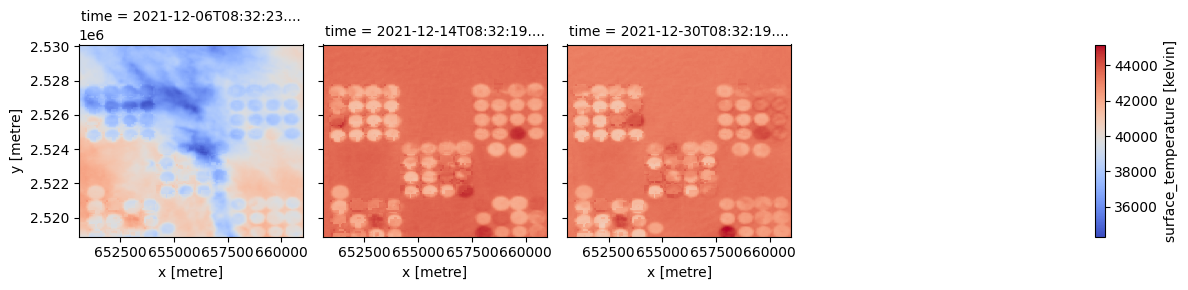

In [26]:
# plot surface temperature

ds['time'] = ds['time'].astype(str)  # Fix KeyError with time format with imshow
ds.surface_temperature.plot.imshow(col='time', col_wrap=4, cmap='coolwarm')

In [27]:
# Remove nodata pixels using the mask criteria previously used

ds = ds.where(~mask_arr).drop_vars('qa_pixel')
ds = ds.dropna('time', how='all')  # Remove empty scenes

***
Even if the legende above mention kelvin, `lazy_ds` values need to be constrained and scaled (as Surface Temperature above but with different values). Let's do it in the next cell and plot again.
***

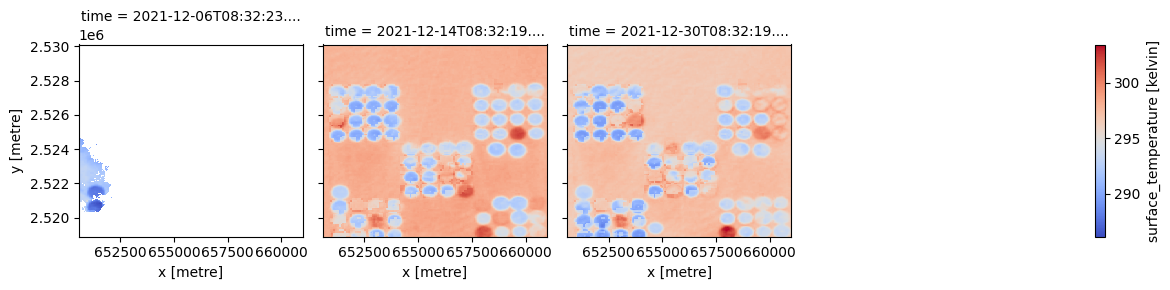

In [28]:
# restrict to Valid Range
ds = ds.where((ds >= 293) & (ds <= 61440), drop=True)

# convert DN to ST (which will give Kelvins)
st = ds * 3.41802e-3 + 149

st['time'] = st['time'].astype(str)  # Fix KeyError with time format with imshow
st.surface_temperature.plot.imshow(col='time', col_wrap=4, cmap='coolwarm')

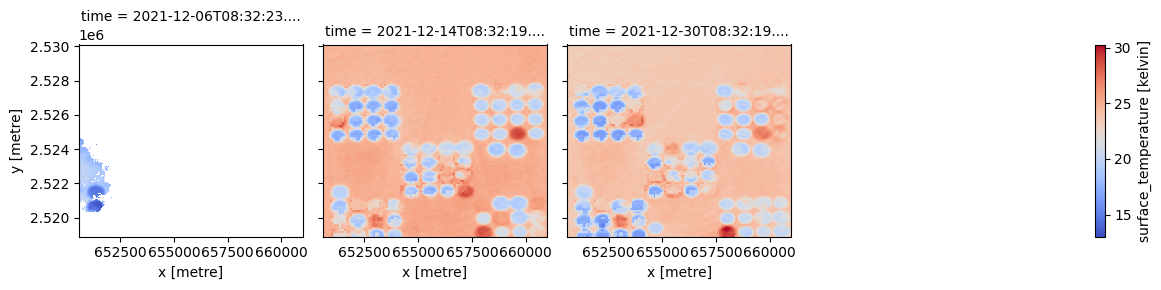

In [29]:
# now convert kelvin into celsius

st = st - 273.15
st.surface_temperature.plot.imshow(col='time', col_wrap=4, cmap='coolwarm')

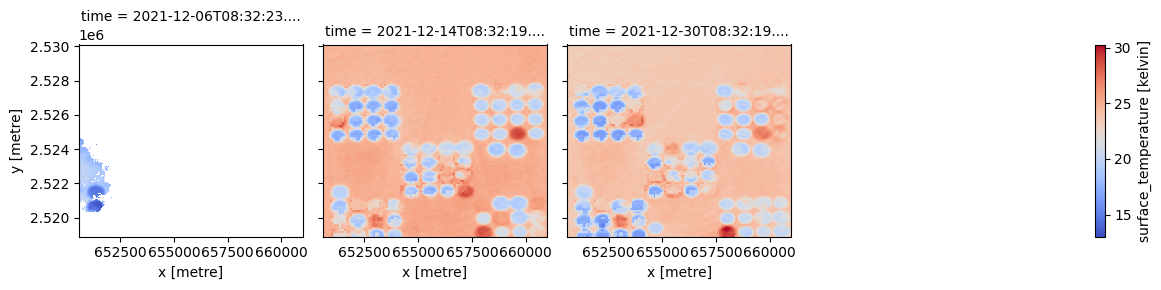

In [30]:
# In case st contains negative and positive values imshow will center
# the colormap on zero, to avoid that you need to manually set vmin and vmax arguments

st.surface_temperature.plot.imshow(col='time', col_wrap=4, cmap='coolwarm',
                                   vmin = st.surface_temperature.min().values,
                                   vmax = st.surface_temperature.max().values)

***

## Additional information

**License:** The code in this notebook is slighly modified from https://github.com/digitalearthafrica/deafrica-sandbox-notebooks and licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [31]:
print(datacube.__version__)

1.9.13


**Last tested:**

In [32]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-02-24'

In [33]:
!pip freeze

affine==2.4.0
ai-edge-litert==2.1.2
aiobotocore==3.1.1
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aioitertools==0.13.0
aiosignal==1.4.0
alembic==1.18.3
annotated-types==0.7.0
antimeridian==0.4.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.1.0
attrs==25.4.0
babel==2.18.0
backports.strenum==1.2.8
beautifulsoup4==4.14.3
bleach==6.3.0
bokeh==3.8.2
boltons==25.0.0
boto3==1.42.30
botocore==1.42.30
branca==0.8.2
cachetools==7.0.0
cattrs==25.3.0
certifi==2026.1.4
certipy==0.2.2
cffi==2.0.0
cftime==1.6.5
charset-normalizer==3.4.4
ciso8601==2.3.3
click==8.1.8
click-plugins==1.1.1.2
cligj==0.7.2
cloudpickle==3.1.2
comm==0.2.3
contourpy==1.3.3
cryptography==46.0.4
cycler==0.12.1
dask==2025.7.0
dask-image==2025.11.0
dask_labextension==7.0.0
datacube==1.9.13
datadog==0.52.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
deprecat==2.1.3
distributed==2025.7.0
eodatasets3==1.9.3
executing==2.2.1
fastjsonschema==2.21.2
fiona==1.10.1
flatbuff